# P1 · 06 — Two more classical tools: Prophet & Theta

Beyond ETS and ARIMA, two widely used approaches:

* **Prophet** (Meta) — an *additive decomposition* model:
  $y_t = \text{trend}_t + \text{seasonality}_t + \text{holidays}_t + \varepsilon_t$,
  fit by a Bayesian backend. Popular for being robust and "hands-off".
* **Theta** — decomposes the series into "theta lines" (essentially SES on the
  deseasonalised data plus half the long-run trend). Simple, fast, and famously
  **won the M3 forecasting competition**.

We hold them to the same backtest as everything else.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

import logging
for _n in ("cmdstanpy", "prophet"):                 # silence the Stan backend
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.disabled = True
from src import baselines as B, backtest as bt, classical as C
q = data.load_quarterly(); nsa = q["gdp_nsa"]

### Prophet: fit and inspect its decomposition

Prophet wants a two-column frame (`ds` = date, `y` = value). We feed it the
quarter-start timestamps and turn on yearly seasonality (our cycle), with
multiplicative seasonality (the swing grows with the level — same reasoning as our
log transform elsewhere).

Importing plotly failed. Interactive plots will not work.


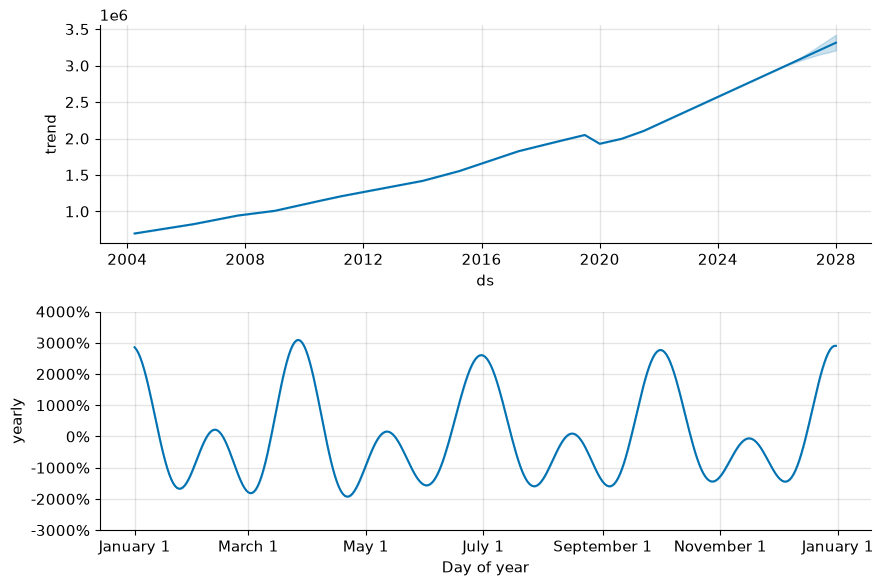

In [2]:
from prophet import Prophet
df = pd.DataFrame({"ds": nsa.index.to_timestamp(how="start"),
                   "y": nsa.to_numpy(dtype=float)})
m = Prophet(seasonality_mode="multiplicative", yearly_seasonality=True,
            weekly_seasonality=False, daily_seasonality=False)
m.fit(df)
future = m.make_future_dataframe(periods=8, freq="QS")
forecast = m.predict(future)
fig = m.plot_components(forecast); plt.show()

The components panel is Prophet's selling point: it shows the inferred **trend**
(with automatic changepoints) and the **yearly seasonal** shape separately — an
interpretable decomposition you can hand to a stakeholder.

### Prophet's forecast with its native interval

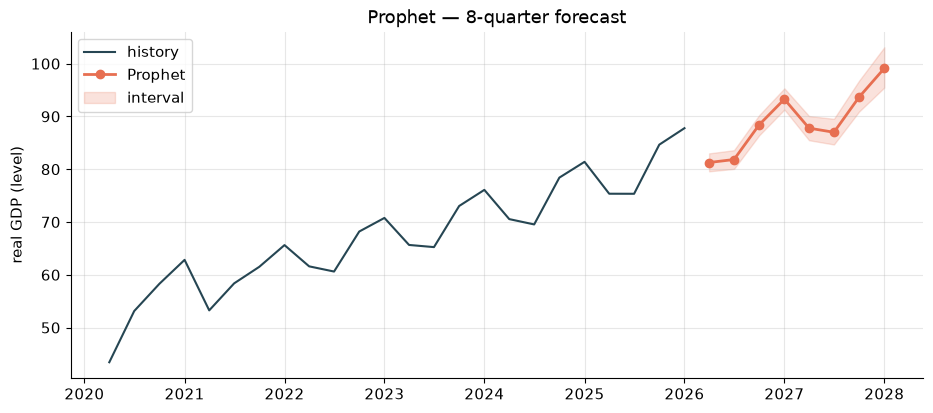

In [3]:
fig, ax = plt.subplots()
hist = nsa.iloc[-24:]
ax.plot(hist.index.to_timestamp(how="start"), hist.values / 1e6,
        color="#264653", label="history")
fut = forecast.tail(8)
ax.plot(fut["ds"], fut["yhat"] / 1e6, color="#e76f51", lw=2, marker="o", label="Prophet")
ax.fill_between(fut["ds"], fut["yhat_lower"] / 1e6, fut["yhat_upper"] / 1e6,
                color="#e76f51", alpha=0.2, label="interval")
ax.set(title="Prophet — 8-quarter forecast", ylabel="real GDP (level)"); ax.legend()
plt.show()

### The backtest verdict (Prophet & Theta vs the field)

Prophet refits a Bayesian model each fold, so it's the slowest model here — we use
`step=2` to thin the folds and keep runtime sane (the MASE estimate stays robust).

In [4]:
fcs = {
    "seasonal_naive(4)": B.seasonal_naive(4),
    "Holt-Winters":      C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4),
    "SARIMA(1,1,1)(0,1,0)4": C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4)),
    "Theta":             C.theta_forecaster(period=4),
    "Prophet":           C.prophet_forecaster(),
}
bt.compare(nsa, fcs, initial=40, h=4, step=2, season_length=4).round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
"SARIMA(1,1,1)(0,1,0)4",1876575.237,3763259.428,3.453,3.467,0.573
Holt-Winters,1991129.585,3558267.177,3.626,3.549,0.608
Prophet,2387811.499,3563751.488,4.190,4.133,0.729
Theta,2404556.269,3252882.922,4.314,4.259,0.734
seasonal_naive(4),4143994.228,4656857.645,7.216,7.389,1.265


Both **Prophet and Theta comfortably beat the baselines** (MASE ≈ 0.73) but land
*behind* the tuned SARIMA/Holt-Winters on this short, clean series. That's a common
real-world pattern: Prophet's strengths — many changepoints, holiday effects, messy
business data with strong multi-seasonality — aren't what a tidy 88-point GDP series
needs. **Theta** punches far above its complexity, which is why it's a respected
benchmark. Lesson: *popular ≠ best for your data* — the backtest decides.

---
**Next (07):** ARIMAX — feeding the model **exogenous** information (deterministic
seasonality and an event dummy).